# LAB 06: NHẬN DIỆN ẢNH (IMAGE DETECTION)
**MSSV:** 2374802010086

**Họ và tên:** Nguyễn Văn Tùng Dương

In [32]:
import subprocess, sys
subprocess.check_call(['uv', 'pip', 'install', 'opencv-python', 'matplotlib', 'numpy',
                        '--break-system-packages', '--python', sys.executable])

0

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as TungDuong

---
## 1. Code mẫu - Nhận diện biển báo STOP

Số đối tượng phát hiện được: 0


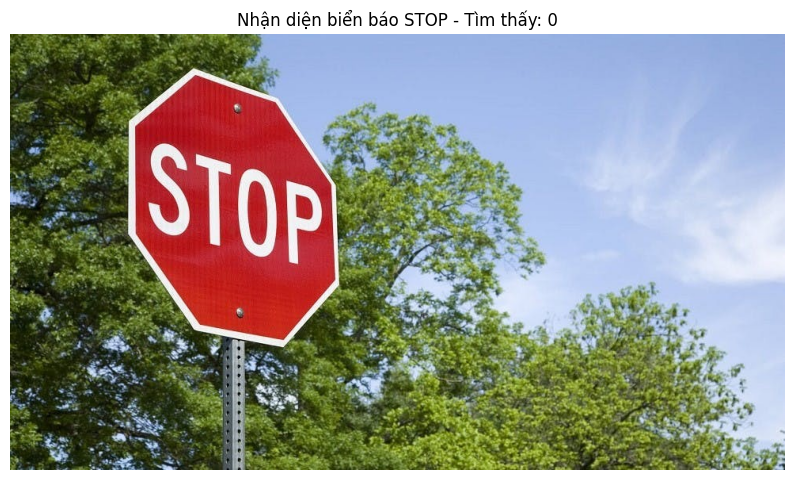

In [34]:
# Đọc ảnh biển báo STOP
img = cv2.imread('image.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Sử dụng CascadeClassifier với file stop_data.xml
stop_data = cv2.CascadeClassifier('stop_data.xml')
found = stop_data.detectMultiScale(img_gray, minSize=(20, 20))
amount_found = len(found)
print(f"Số đối tượng phát hiện được: {amount_found}")

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)

TungDuong.figure(figsize=(10, 6))
TungDuong.imshow(img_rgb)
TungDuong.title(f'Nhận diện biển báo STOP - Tìm thấy: {amount_found}')
TungDuong.axis('off')
TungDuong.show()

---
## 2. Nhận diện khuôn mặt (Face Detection)

Số khuôn mặt phát hiện được: 5


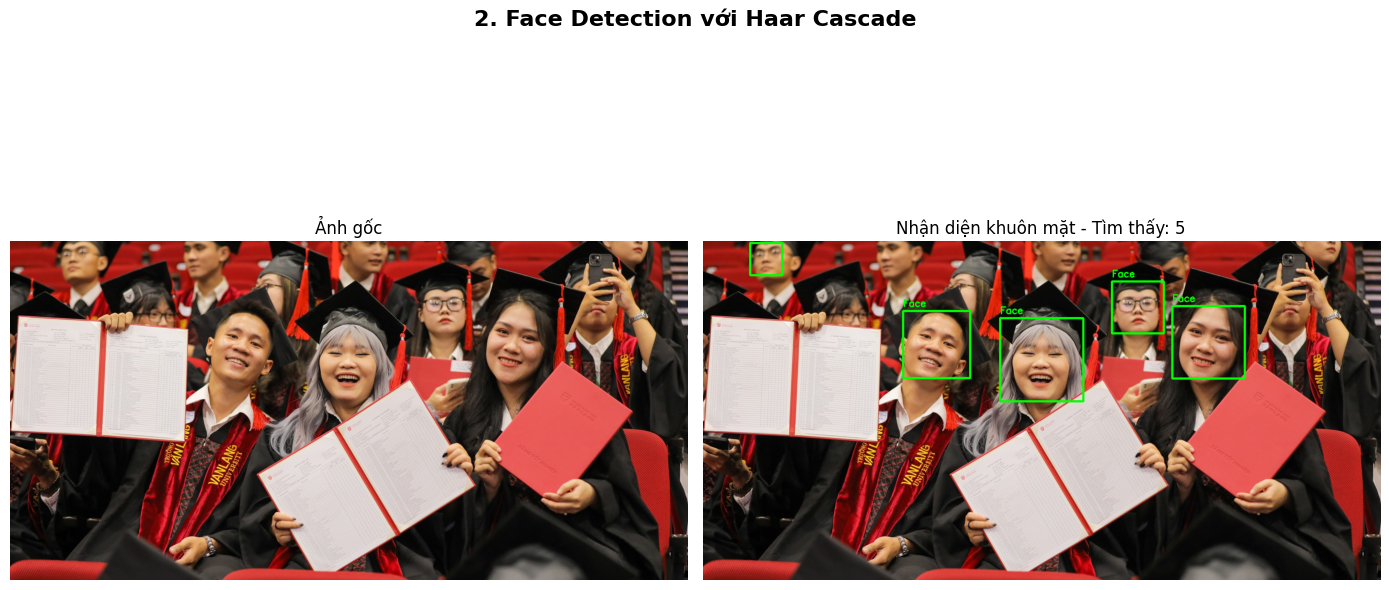

In [35]:
# Đọc ảnh có khuôn mặt
img2 = cv2.imread('face.jpg')
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Sử dụng Haar Cascade để nhận diện khuôn mặt
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(
    img2_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)
print(f"Số khuôn mặt phát hiện được: {len(faces)}")

# Vẽ hình chữ nhật quanh khuôn mặt
img2_face = img2_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img2_face, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.putText(img2_face, 'Face', (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

# Hiển thị kết quả
TungDuong.figure(figsize=(14, 8))

TungDuong.subplot(1, 2, 1)
TungDuong.imshow(img2_rgb)
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

TungDuong.subplot(1, 2, 2)
TungDuong.imshow(img2_face)
TungDuong.title(f'Nhận diện khuôn mặt - Tìm thấy: {len(faces)}')
TungDuong.axis('off')

TungDuong.suptitle('2. Face Detection với Haar Cascade', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 3. Nhận diện khuôn mặt + Mắt (Face & Eye Detection)

Số khuôn mặt: 5
Tổng số mắt phát hiện: 6


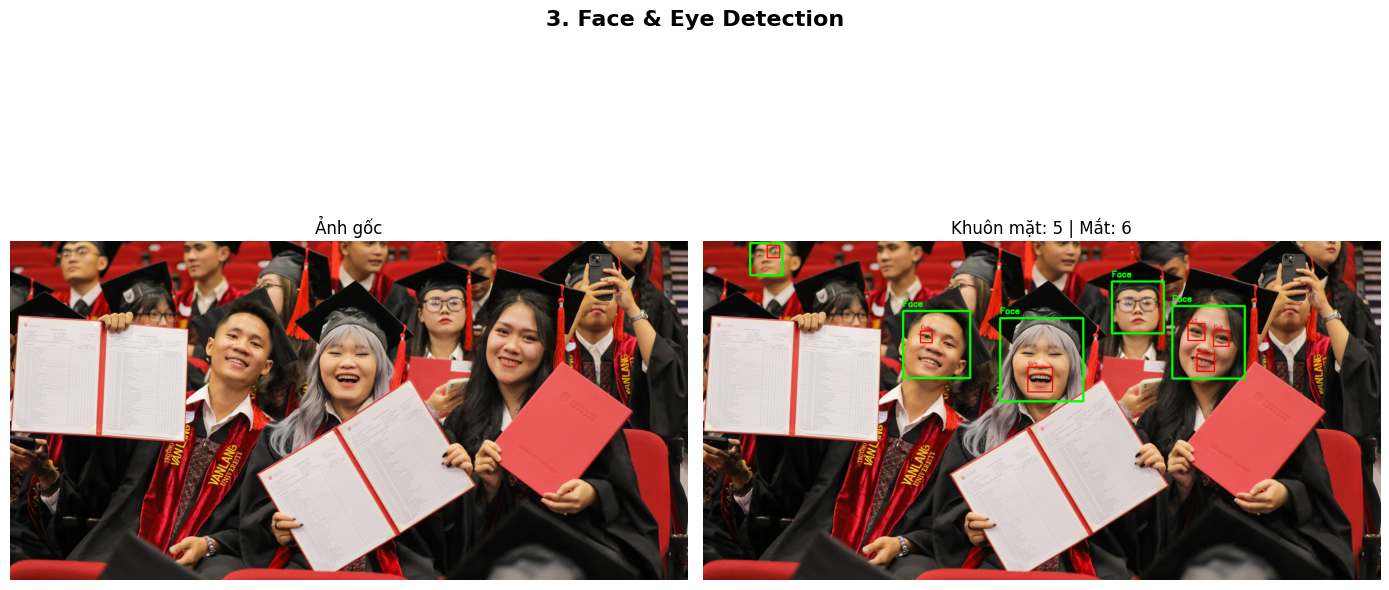

In [36]:
# Đọc lại ảnh
img3 = cv2.imread('face.jpg')
img3_gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
img3_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

# Load cascade cho khuôn mặt và mắt
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

# Phát hiện khuôn mặt
faces = face_cascade.detectMultiScale(
    img3_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

total_eyes = 0
img3_result = img3_rgb.copy()

for (x, y, w, h) in faces:
    # Vẽ hình chữ nhật quanh khuôn mặt (màu xanh lá)
    cv2.rectangle(img3_result, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.putText(img3_result, 'Face', (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Vùng ROI trong khuôn mặt để tìm mắt
    roi_gray = img3_gray[y:y+h, x:x+w]
    roi_color = img3_result[y:y+h, x:x+w]

    # Phát hiện mắt trong vùng khuôn mặt
    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=10,
        minSize=(15, 15)
    )

    for (ex, ey, ew, eh) in eyes:
        # Vẽ hình chữ nhật quanh mắt (màu xanh dương)
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)
        cv2.putText(roi_color, 'Eye', (ex, ey - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
        total_eyes += 1

print(f"Số khuôn mặt: {len(faces)}")
print(f"Tổng số mắt phát hiện: {total_eyes}")

# Hiển thị kết quả
TungDuong.figure(figsize=(14, 8))

TungDuong.subplot(1, 2, 1)
TungDuong.imshow(img3_rgb)
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

TungDuong.subplot(1, 2, 2)
TungDuong.imshow(img3_result)
TungDuong.title(f'Khuôn mặt: {len(faces)} | Mắt: {total_eyes}')
TungDuong.axis('off')

TungDuong.suptitle('3. Face & Eye Detection', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 4. Nhận diện khuôn mặt + Nụ cười (Face & Smile Detection)

Số khuôn mặt: 5
Số nụ cười phát hiện: 1


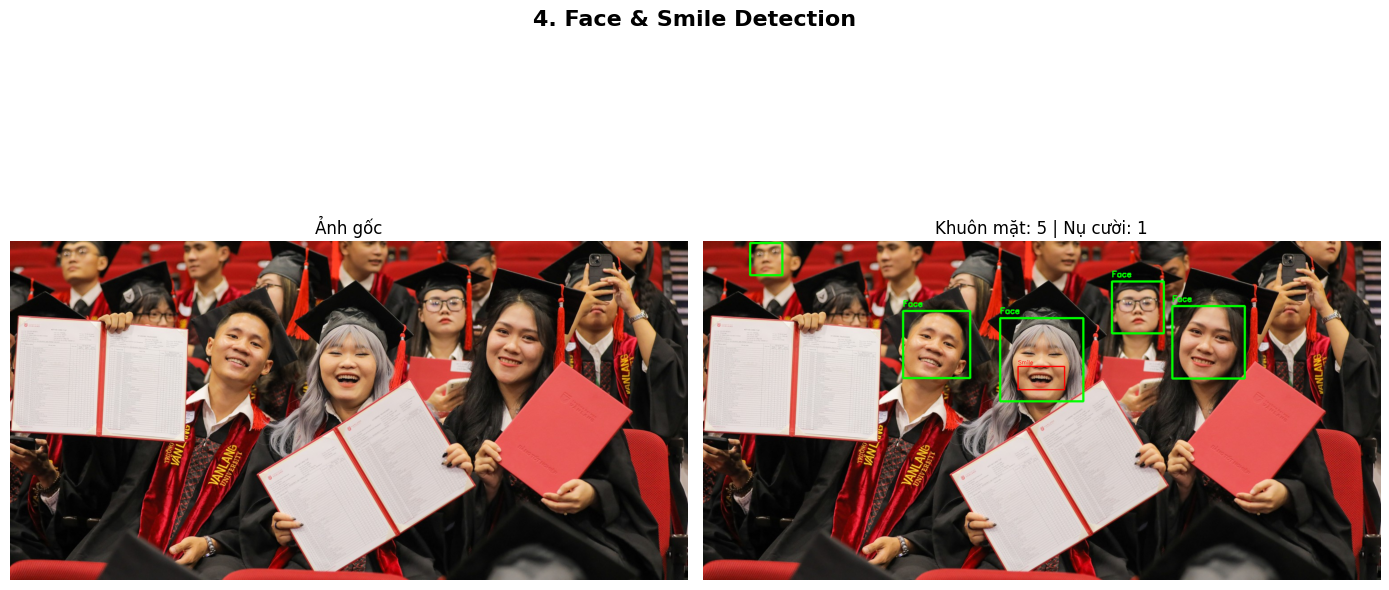

In [37]:
# Đọc lại ảnh
img4 = cv2.imread('face.jpg')
img4_gray = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)
img4_rgb = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

# Load cascade cho khuôn mặt và nụ cười
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')

# Phát hiện khuôn mặt
faces = face_cascade.detectMultiScale(
    img4_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

total_smiles = 0
img4_result = img4_rgb.copy()

for (x, y, w, h) in faces:
    # Vẽ hình chữ nhật quanh khuôn mặt (màu xanh lá)
    cv2.rectangle(img4_result, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.putText(img4_result, 'Face', (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # Vùng ROI phần dưới khuôn mặt (nụ cười thường ở nửa dưới)
    roi_gray = img4_gray[y + h // 2:y + h, x:x + w]
    roi_color = img4_result[y + h // 2:y + h, x:x + w]

    # Phát hiện nụ cười
    smiles = smile_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25)
    )

    for (sx, sy, sw, sh) in smiles:
        # Vẽ hình chữ nhật quanh nụ cười (màu đỏ)
        cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (255, 0, 0), 2)
        cv2.putText(roi_color, 'Smile', (sx, sy - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
        total_smiles += 1

print(f"Số khuôn mặt: {len(faces)}")
print(f"Số nụ cười phát hiện: {total_smiles}")

# Hiển thị kết quả
TungDuong.figure(figsize=(14, 8))

TungDuong.subplot(1, 2, 1)
TungDuong.imshow(img4_rgb)
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

TungDuong.subplot(1, 2, 2)
TungDuong.imshow(img4_result)
TungDuong.title(f'Khuôn mặt: {len(faces)} | Nụ cười: {total_smiles}')
TungDuong.axis('off')

TungDuong.suptitle('4. Face & Smile Detection', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()

---
## 5. Tổng hợp - Nhận diện Khuôn mặt + Mắt + Nụ cười

Tổng kết:
  - Khuôn mặt: 5
  - Mắt: 3
  - Nụ cười: 1


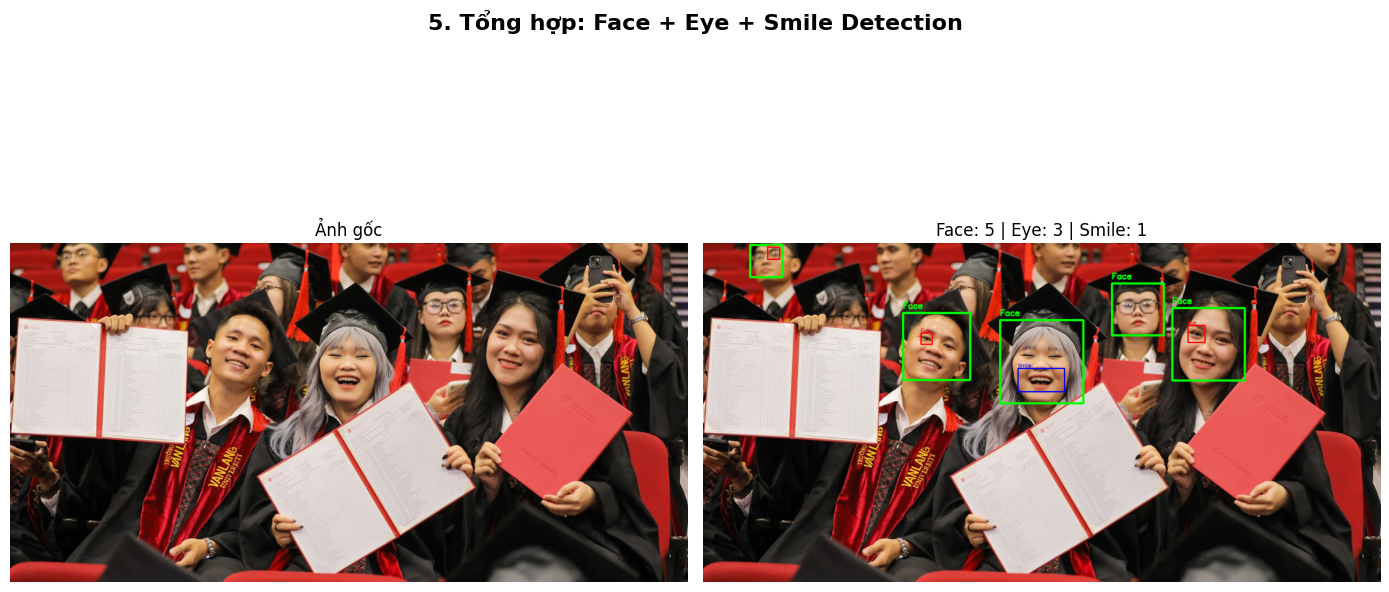

In [38]:
# Đọc lại ảnh
img5 = cv2.imread('face.jpg')
img5_gray = cv2.cvtColor(img5, cv2.COLOR_BGR2GRAY)
img5_rgb = cv2.cvtColor(img5, cv2.COLOR_BGR2RGB)

# Load tất cả cascade
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')

# Phát hiện khuôn mặt
faces = face_cascade.detectMultiScale(
    img5_gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

total_eyes = 0
total_smiles = 0
img5_result = img5_rgb.copy()

for (x, y, w, h) in faces:
    # Vẽ khuôn mặt (xanh lá)
    cv2.rectangle(img5_result, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.putText(img5_result, 'Face', (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    roi_gray = img5_gray[y:y+h, x:x+w]
    roi_color = img5_result[y:y+h, x:x+w]

    # Phát hiện mắt (nửa trên khuôn mặt)
    roi_gray_upper = roi_gray[0:h//2, :]
    roi_color_upper = roi_color[0:h//2, :]
    eyes = eye_cascade.detectMultiScale(
        roi_gray_upper,
        scaleFactor=1.1,
        minNeighbors=10,
        minSize=(15, 15)
    )
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color_upper, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)
        cv2.putText(roi_color_upper, 'Eye', (ex, ey - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 0, 0), 1)
        total_eyes += 1

    # Phát hiện nụ cười (nửa dưới khuôn mặt)
    roi_gray_lower = roi_gray[h//2:, :]
    roi_color_lower = roi_color[h//2:, :]
    smiles = smile_cascade.detectMultiScale(
        roi_gray_lower,
        scaleFactor=1.7,
        minNeighbors=22,
        minSize=(25, 25)
    )
    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color_lower, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)
        cv2.putText(roi_color_lower, 'Smile', (sx, sy - 3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 0, 255), 1)
        total_smiles += 1

print(f"Tổng kết:")
print(f"  - Khuôn mặt: {len(faces)}")
print(f"  - Mắt: {total_eyes}")
print(f"  - Nụ cười: {total_smiles}")

# Hiển thị kết quả
TungDuong.figure(figsize=(14, 8))

TungDuong.subplot(1, 2, 1)
TungDuong.imshow(img5_rgb)
TungDuong.title('Ảnh gốc')
TungDuong.axis('off')

TungDuong.subplot(1, 2, 2)
TungDuong.imshow(img5_result)
TungDuong.title(f'Face: {len(faces)} | Eye: {total_eyes} | Smile: {total_smiles}')
TungDuong.axis('off')

TungDuong.suptitle('5. Tổng hợp: Face + Eye + Smile Detection', fontsize=16, fontweight='bold')
TungDuong.tight_layout()
TungDuong.show()